In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [96]:
training_data = pd.read_csv("Training.csv")
testing_data = pd.read_csv("Testing.csv")

In [97]:
training_data.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [98]:
testing_data.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Allergy
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,GERD
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Chronic cholestasis
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Drug Reaction


In [99]:
training_data.shape

(4920, 134)

In [100]:
testing_data.shape

(42, 133)

In [101]:
training_data = training_data.dropna(axis=1 , how='all')     # Drop columns with all NaN values
training_data.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [102]:
training_data["prognosis"].value_counts()            # checking the distribution of target variable

prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hep

In [103]:
training_data.describe().T

,count,mean,std,min,25%,50%,75%,max
itching,4920.0,0.137805,0.344730,0.0,0.0,0.0,0.0,1.0
skin_rash,4920.0,0.159756,0.366417,0.0,0.0,0.0,0.0,1.0
nodal_skin_eruptions,4920.0,0.021951,0.146539,0.0,0.0,0.0,0.0,1.0
continuous_sneezing,4920.0,0.045122,0.207593,0.0,0.0,0.0,0.0,1.0
shivering,4920.0,0.021951,0.146539,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
small_dents_in_nails,4920.0,0.023171,0.150461,0.0,0.0,0.0,0.0,1.0
inflammatory_nails,4920.0,0.023171,0.150461,0.0,0.0,0.0,0.0,1.0
blister,4920.0,0.023171,0.150461,0.0,0.0,0.0,0.0,1.0
red_sore_around_nose,4920.0,0.023171,0.150461,0.0,0.0,0.0,0.0,1.0


In [104]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), str(1)
memory usage: 5.1 MB


In [105]:
training_data.isnull().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64

In [106]:
# separate x and y(for training data)
x_train = training_data.drop("prognosis", axis=1)
y_train = training_data["prognosis"]

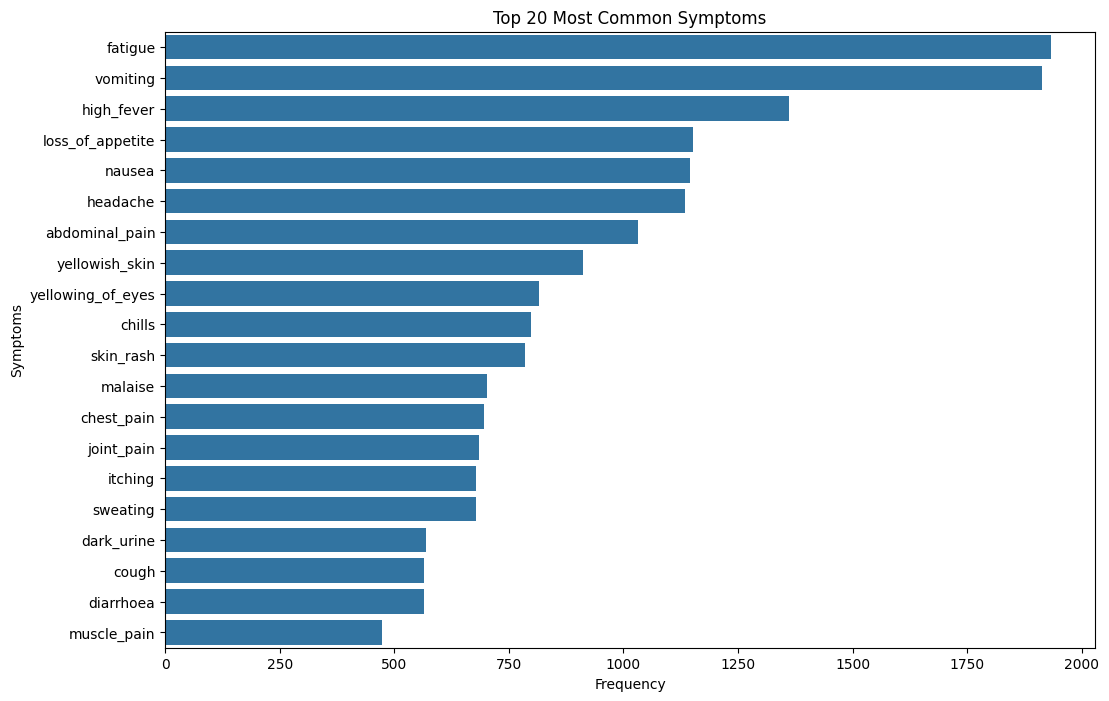

In [107]:
# Visulaizing top 20 most common symptom

symptom_counts = x_train.sum()

top_symptoms = symptom_counts.sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_symptoms.values,
    y=top_symptoms.index
)

plt.title("Top 20 Most Common Symptoms")

plt.xlabel("Frequency")

plt.ylabel("Symptoms")

plt.show()

In [108]:
# separate x and y (for testing data)
x_test = testing_data.drop("prognosis", axis=1)
y_test = testing_data["prognosis"]

In [109]:
# encode target variable
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)


In [110]:
# feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [111]:
# initialize and train the model for Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train_encoded)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [112]:
# Make prediction for testing data
from sklearn.metrics import accuracy_score

rf_pred = rf_model.predict(x_test)
rf_acc = accuracy_score(y_test_encoded, rf_pred)


In [113]:
# Evaluate the model



print("Accuracy", accuracy_score(y_test_encoded, rf_pred))
print("Classification Report:\n", classification_report(y_test_encoded, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, rf_pred))

Accuracy 0.9761904761904762
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      0.50      0.67         2
          16       1.00      

In [114]:
# Logistics Regression
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(x_train, y_train_encoded)
log_pred = log_model.predict(x_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test_encoded, log_pred))
print("Classification Report:\n", classification_report(y_test_encoded, log_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, log_pred))

Logistic Regression Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         2
          16       1.00

In [115]:
# SVM
from sklearn.svm import SVC 
svm_model = SVC(random_state=42)
svm_model.fit(x_train, y_train_encoded)
svm_pred = svm_model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test_encoded, svm_pred))        
print("Classification Report:\n", classification_report(y_test_encoded, svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, svm_pred))


SVM Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         2
          16       1.00      1.00      

In [116]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train_encoded)
knn_pred = knn_model.predict(x_test)
print("KNN Accuracy:", accuracy_score(y_test_encoded, knn_pred))
print("Classification Report:\n", classification_report(y_test_encoded, knn_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, knn_pred))

KNN Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         2
          16       1.00      1.00      

In [117]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(x_train, y_train_encoded)
nb_pred = nb_model.predict(x_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test_encoded, nb_pred))
print("Classification Report:\n", classification_report(y_test_encoded, nb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, nb_pred))



Naive Bayes Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         2
          16       1.00      1.

In [118]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train_encoded)
dt_pred = dt_model.predict(x_test)
print("Decision Tree Accuracy:", accuracy_score(y_test_encoded, dt_pred))
print("Classification Report:\n", classification_report(y_test_encoded, dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, dt_pred))

Decision Tree Accuracy: 0.9761904761904762
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      0.50      0.67         2
          16  

In [119]:
# Priniting all the accuracies together
print("Random Forest Accuracy:", accuracy_score(y_test_encoded, rf_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test_encoded, log_pred))
print("SVM Accuracy:", accuracy_score(y_test_encoded, svm_pred))
print("KNN Accuracy:", accuracy_score(y_test_encoded, knn_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test_encoded, nb_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test_encoded, dt_pred))


Random Forest Accuracy: 0.9761904761904762
Logistic Regression Accuracy: 1.0
SVM Accuracy: 1.0
KNN Accuracy: 1.0
Naive Bayes Accuracy: 1.0
Decision Tree Accuracy: 0.9761904761904762


In [120]:
# checking training accuracy
rf_train_pred = rf_model.predict(x_train)
print("Random Forest Training Accuracy:", accuracy_score(y_train_encoded, rf_train_pred))

log_train_pred = log_model.predict(x_train)
print("Logistic Regression Training Accuracy:", accuracy_score(y_train_encoded, log_train_pred))

svm_train_pred = svm_model.predict(x_train)
print("SVM Training Accuracy:", accuracy_score(y_train_encoded, svm_train_pred))

knn_train_pred = knn_model.predict(x_train)
print("KNN Training Accuracy:", accuracy_score(y_train_encoded, knn_train_pred))

nb_train_pred = nb_model.predict(x_train)
print("Naive Bayes Training Accuracy:", accuracy_score(y_train_encoded, nb_train_pred))

dt_train_pred = dt_model.predict(x_train)
print("Decision Tree Training Accuracy:", accuracy_score(y_train_encoded, dt_train_pred))


Random Forest Training Accuracy: 1.0
Logistic Regression Training Accuracy: 1.0
SVM Training Accuracy: 1.0
KNN Training Accuracy: 1.0
Naive Bayes Training Accuracy: 1.0
Decision Tree Training Accuracy: 1.0


In [121]:
# cross validation for all the models
from sklearn.model_selection import cross_val_score
rf_cv_scores = cross_val_score(rf_model, x_train, y_train_encoded, cv=5)
log_cv_scores = cross_val_score(log_model, x_train, y_train_encoded, cv=5)
svm_cv_scores = cross_val_score(svm_model, x_train, y_train_encoded, cv=5)
knn_cv_scores = cross_val_score(knn_model, x_train, y_train_encoded, cv=5)
nb_cv_scores = cross_val_score(nb_model, x_train, y_train_encoded, cv=5)
dt_cv_scores = cross_val_score(dt_model, x_train, y_train_encoded, cv=5)
print("Random Forest CV Scores:", rf_cv_scores)
print("Logistic Regression CV Scores:", log_cv_scores)
print("SVM CV Scores:", svm_cv_scores)
print("KNN CV Scores:", knn_cv_scores)
print("Naive Bayes CV Scores:", nb_cv_scores)
print("Decision Tree CV Scores:", dt_cv_scores)



Random Forest CV Scores: [1. 1. 1. 1. 1.]
Logistic Regression CV Scores: [1. 1. 1. 1. 1.]
SVM CV Scores: [1. 1. 1. 1. 1.]
KNN CV Scores: [1. 1. 1. 1. 1.]
Naive Bayes CV Scores: [1. 1. 1. 1. 1.]
Decision Tree CV Scores: [1. 1. 1. 1. 1.]


In [122]:
# save and load the model for random forest

# save the trained model and the encoder
import joblib

joblib.dump(rf_model, "disease_prediction_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")


['label_encoder.pkl']

In [123]:
# load the model and encoder
loaded_model = joblib.load("disease_prediction_model.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")